# Optisches Pumpen

m = 0.588359444959464 +/- 0.0003968745642535669 Ohm
Widerstand = 1.699641279777359 +/- 0.0011464834941937374 Ohm


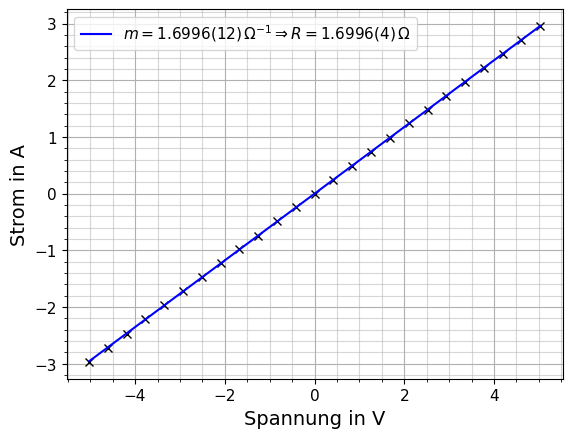

In [45]:
# Widerstand bestimmen
# Achtung, es muss auf dem Poster noch die Formel dazu, die rechtfertigt, dass der Gesamtwiderstand gleich dem Widerstand einer der Spulen ist
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

spannung, strom= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/2_Spannung_Strom.dat', skiprows=1, unpack=True, delimiter='\t')

fitwiderstandinv = linregress(spannung, strom)
R, R_err = 1/fitwiderstandinv.slope, 1/fitwiderstandinv.slope**2 *fitwiderstandinv.stderr

print(f"m = {fitwiderstandinv.slope} +/- {fitwiderstandinv.stderr} Ohm")
print(f"Widerstand = {R} +/- {R_err} Ohm")

fig, ax = plt.subplots()

ax.plot(spannung, strom, "xk")
ax.plot(spannung, fitwiderstandinv.intercept+fitwiderstandinv.slope*spannung, "-b", label=r"$m=1.6996(12)\, \Omega^{-1} \Rightarrow R=1.6996(4)\,\Omega$")

ax.set_xlabel("Spannung in V", fontsize=14)
ax.set_ylabel("Strom in A", fontsize=14)
ax.tick_params(labelsize=11)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.legend(fontsize=11)

tau = 2.7067984102889313 +/- 0.015985430913119828 ms
Induktivität = 4.6005863141628005 +/- 0.030272797954473647 mH


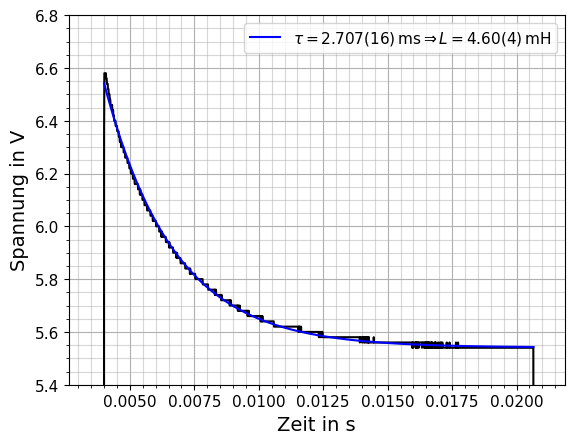

In [48]:
#Induktivität der Spulen bestimmen
from scipy.optimize import curve_fit

def f(t, U0, Uind, tau):
    return U0 + Uind*np.exp(-t/tau)

# fit für Abklingen des zusätzlichen Peaks am Rechtecksignal mit Annahme von Selbstinduktion
zeit, spannung= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/3_Induktivität_Abklingzeit_Übersicht_Stromverst_30Hz_12Vpp.dat', skiprows=0, unpack=True, delimiter='\t')

mask = np.where(spannung>2.48)

p0 = (5, 4, 0.003)

popt, pcov = curve_fit(f, zeit[mask], spannung[mask], p0)
stderr = np.sqrt(np.diag(pcov))
tau, tau_err = popt[2], stderr[2]

print(f"tau = {tau*10**3} +/- {tau_err*10**3} ms")
print(f"Induktivität = {tau*R*10**3} +/- {(tau*R_err + R*tau_err)*10**3} mH")

fig, ax = plt.subplots()

ax.plot(zeit[350:2100], spannung[350:2100], "-k")
ax.plot(zeit[mask], f(zeit[mask],popt[0],popt[1],popt[2]), "-b", label=r"$\tau=2.707(16)\,\text{ms} \Rightarrow L=4.60(4)\,\text{mH}$")

ax.set_xlabel("Zeit in s", fontsize=14)
ax.set_ylabel("Spannung in V", fontsize=14)
ax.tick_params(labelsize=11)
ax.set_ylim(5.4,6.8)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.legend(fontsize=11)

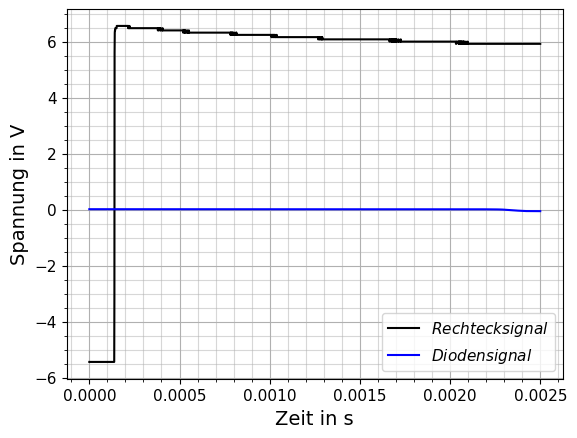

In [52]:
#Test, ob die Induktivität der Spule für die Zeitverzögerung im Diodensignal verantwortlich ist

zeit, rechteck, diode= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/3_großer_Zeitversatz_Stromverst_Diode_30Hz_12Vpp.dat', skiprows=0, unpack=True, delimiter='\t')

fig, ax = plt.subplots()

ax.plot(zeit, rechteck, "-k", label=r"$Rechtecksignal$")
ax.plot(zeit, diode, "-b", label=r"$Diodensignal$")

ax.set_xlabel("Zeit in s", fontsize=14)
ax.set_ylabel("Spannung in V", fontsize=14)
ax.tick_params(labelsize=11)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.legend(fontsize=11)

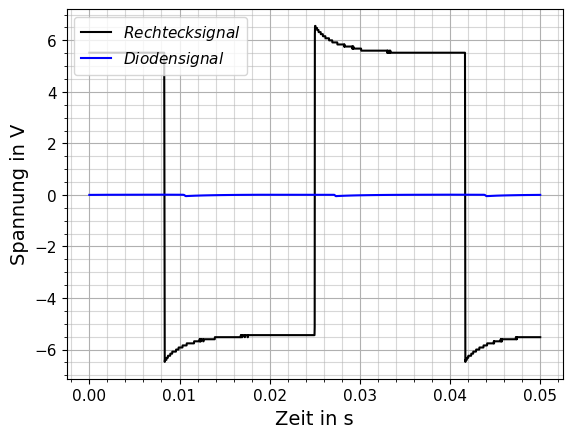

In [54]:
#Bestimmung der Orientierungszeit

def g(t, U0, Uind, tau):
    return U0 + Uind*np.exp(-t/tau)

z30Hz, r30Hz, d30Hz= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/3_Übersicht_Stromverst_Diode_30Hz_12Vpp.dat', skiprows=0, unpack=True, delimiter='\t')

#mask = np.where(spannung>2.48)

#p0 = (5, 4, 0.003)

#popt, pcov = curve_fit(f, zeit[mask], spannung[mask], p0)
#stderr = np.sqrt(np.diag(pcov))
#tau, tau_err = popt[2], stderr[2]

#print(f"tau = {tau*10**3} +/- {tau_err*10**3} ms")

fig, ax = plt.subplots()
ax.plot(z30Hz, r30Hz, "-k", label=r"$Rechtecksignal$")
ax.plot(z30Hz, d30Hz, "-b", label=r"$Diodensignal$")

ax.set_xlabel("Zeit in s", fontsize=14)
ax.set_ylabel("Spannung in V", fontsize=14)
ax.tick_params(labelsize=11)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.legend(fontsize=11)

In [ ]:
#Visualisierung der Erdmagnetfeldbestimmung

In [ ]:
#RF-Messung bei moduliertem Magnetfeld -> g-Faktor

In [ ]:
#RF-Sweep bei festem Magnetfeld -> g-Faktor